# EE-411 Lottery Ticket Hypothesis - Experiment Resnet-18 + Iterative + Original Init

**Author:** Tianrui (Jerry)
**Model:** ResNet 18
**Dataset:** [CIFAR-10]  
**Date:** [2026.01.11]

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## Setup Run ID

In [1]:
import os
import time
from datetime import datetime

# 1. Generate a unique Run ID (Model + Timestamp)
# e.g., "resnet20_20231027_153045"
model_name = "resnet20_iterative_original_init"  # Or "resnet18"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_id = f"{model_name}_{timestamp}"

# 2. Create specific directories for THIS run
# Instead of dumping everything in 'results/', we make a subfolder
base_dir = "../../results"
run_dir = os.path.join(base_dir, run_id)
ckpt_dir = os.path.join(run_dir, "checkpoints")
fig_dir = os.path.join(run_dir, "figures")

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

print(f"Experiment Initialized: {run_id}")
print(f"Results will be saved to: {run_dir}")

Experiment Initialized: resnet20_iterative_original_init_20260111_183314
Results will be saved to: ../../results/resnet20_iterative_original_init_20260111_183314


## 1. Setup and Imports

In [2]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    one_shot_pruning_efficient,
    random_reinit_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model,
    apply_mask,
    create_global_mask
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading

### For CIFAR-10 (Conv-2, Conv-4, Conv-6, ResNet-18)

In [3]:
# CIFAR-10 Data Loading


# Define transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # New ! Crucial for CIFAR-10 
    transforms.RandomHorizontalFlip(),     # New ! Crucial for generalization 
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])


# ============================================================================
# 2. Download and Load Datasets (Twice!)
# ============================================================================

# transform_train
train_set_augmented = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_train  # <--- Augmented data
)

# transform_test
train_set_clean = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_test   # <--- Clean data
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=False, 
    download=True, 
    transform=transform_test
)



# ============================================================================
# 3. Split Train/Val using Indices
# ============================================================================
# Make sure it's able to reproduce the same split every time
num_train = len(train_set_augmented) # 50000
indices = list(range(num_train))
split = 45000
seed = 42 

np.random.seed(seed)
np.random.shuffle(indices)

train_idx = indices[:split]
val_idx = indices[split:]

# train_dataset
train_dataset = Subset(train_set_augmented, train_idx)
# val_dataset construction using clean data
val_dataset   = Subset(train_set_clean, val_idx)


# ============================================================================
# 4. Create Data Loaders
# ============================================================================
# Create data loaders
# batch_size = 60  # From paper
batch_size = 128  # Paper uses 128 for ResNet-18

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

# ============================================================================
# 5. Verify & Config Check
# ============================================================================

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

# Automatic Epochs Recommendation
iterations_needed = 30000
steps_per_epoch = len(train_loader)
recommended_epochs = int(np.ceil(iterations_needed / steps_per_epoch))

print(f"\n[Config Check]")
print(f"To reach {iterations_needed} iterations with batch size {batch_size}:")
print(f"You should set EPOCHS >= {recommended_epochs}")

Train: 45000 samples
Val:   5000 samples
Test:  10000 samples
Batches per epoch: 352

[Config Check]
To reach 30000 iterations with batch size 128:
You should set EPOCHS >= 86


### For MNIST (LeNet)

In [ ]:
# MNIST Data Loading (Uncomment if using LeNet)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])

# train_dataset_full = torchvision.datasets.MNIST(
#     root='../../data',
#     train=True,
#     download=True,
#     transform=transform
# )

# test_dataset = torchvision.datasets.MNIST(
#     root='../../data',
#     train=False,
#     download=True,
#     transform=transform
# )

# # Split train/val (55k train, 5k val)
# train_size = 55000
# val_size = 5000
# train_dataset, val_dataset = random_split(
#     train_dataset_full,
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(seed)
# )

# batch_size = 60

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# print(f"Train: {len(train_dataset)} samples")
# print(f"Val:   {len(val_dataset)} samples")
# print(f"Test:  {len(test_dataset)} samples")

## 3. Model Definition

**TODO: Define your model here**

In [ ]:
# ResNet18 for CIFAR-10
import copy
import torch
import torch.nn as nn
# from torchvision.models import resnet18
import torch.nn.functional as F
import torch.nn.init as init



# ResNet-20 for CIFAR-10 (Kaiming He, used in the paper)
def _weights_init(m):
    """
    Kaiming Initialization (He Initialization) as used in the paper.
    """
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        init.kaiming_normal_(m.weight)


# def _weights_init(m):
#     """
#     Paper uses Gaussian Glorot (Xavier Normal) initialization.
#     """
#     if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
#         # 论文使用的是 Gaussian Glorot (Xavier Normal)
#         init.xavier_normal_(m.weight)
#         # 如果有 bias，通常初始化为 0 (虽然 ResNet 的 Conv 通常没有 bias)
#         if m.bias is not None:
#             init.constant_(m.bias, 0)

class LambdaLayer(nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.downsample = nn.Sequential() # named as "downsample" as pruning.py
        if stride != 1 or in_planes != planes:
            # Paper Option A: Zero-padding for shortcut
            self.downsample = LambdaLayer(lambda x:
                                        F.pad(x[:, :, ::2, ::2], (0, 0, 0, 0, planes//4, planes//4), "constant", 0))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.downsample(x)
        out = F.relu(out)
        return out

class ResNet20_CIFAR10(nn.Module):
    def __init__(self):
        super(ResNet20_CIFAR10, self).__init__()
        self.in_planes = 16
        
        # ResNet-20: 3 layers * 3 blocks * 2 convs + 1st conv + 1 linear = 20 layers
        num_blocks = [3, 3, 3] 

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(BasicBlock, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock, 64, num_blocks[2], stride=2)
        
        self.linear = nn.Linear(64, 10)
        
        # Apply initialization
        self.apply(_weights_init)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out



# Create model instance
# model = ResNet18_CIFAR10().to(device)
model = ResNet20_CIFAR10().to(device)
initial_weights_state = copy.deepcopy(model.state_dict())
init_weights_path = os.path.join(ckpt_dir, f"initial_weights_theta0_{run_id}.pth")
torch.save(initial_weights_state, init_weights_path)
print(f"Initial weights saved to: {init_weights_path}")

# Print model info
total_params = count_parameters(model)
print(f"Model: ResNet20_CIFAR10")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Initial weights saved to: ../../results/resnet20_iterative_original_init_20260111_183314/checkpoints/initial_weights_theta0_resnet20_iterative_original_init_20260111_183314.pth
Model: ResNet20_CIFAR10
Total parameters: 269,722

Model architecture:
ResNet20_CIFAR10(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1),

## 4. Baseline Training

Train the unpruned model to establish baseline performance.

In [5]:
# Training configuration (from paper)
# Adjust these based on your model!
     
learning_rate = 0.1 # Paper recommends 0.1 (or 0.03 with warmup)
epochs = 86  

# Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=learning_rate,             # Paper recommends 0.1 for constant, or 0.03 with warmup
    momentum=0.9, 
    weight_decay=1e-4   # Helps prevent overfitting
)

# Paper: Divide LR by 10 at 20k and 25k iterations
# 20,000 / 352 ≈ 57 epochs
# 25,000 / 352 ≈ 71 epochs
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, 
    milestones=[57, 71], 
    gamma=0.1
)

# --- Dynamic Print ---
optimizer_name = optimizer.__class__.__name__
current_lr = optimizer.param_groups[0]['lr']

print(f"Training configuration:")
# print(f"  Optimizer: Adam")
# print(f"  Optimizer: SGD")
print(f"  Optimizer: {optimizer_name}") # Dynamic!
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"\nStarting training...\n")

test_loss, test_accuracy = predict(model, test_loader, device)

Training configuration:
  Optimizer: SGD
  Learning rate: 0.1
  Epochs: 86
  Batch size: 128

Starting training...

Test set: Avg. loss: 63.2978, Accuracy: 1000/10000 (10%)


In [ ]:
# # Train using shared training_utils
# losses = fit(
#     model=model,
#     train_dataloader=train_loader,
#     optimizer=optimizer,
#     epochs=epochs,
#     device=device,
#     scheduler=scheduler  # New! Don't forget to pass the scheduler!
# )

# # Evaluate on test set
# test_loss, test_accuracy = predict(model, test_loader, device)

# print(f"\n{'='*60}")
# print(f"Baseline Results")
# print(f"{'='*60}")
# print(f"Test Accuracy: {test_accuracy:.2f}%")
# print(f"Test Loss: {test_loss:.4f}")

### Visualize Training

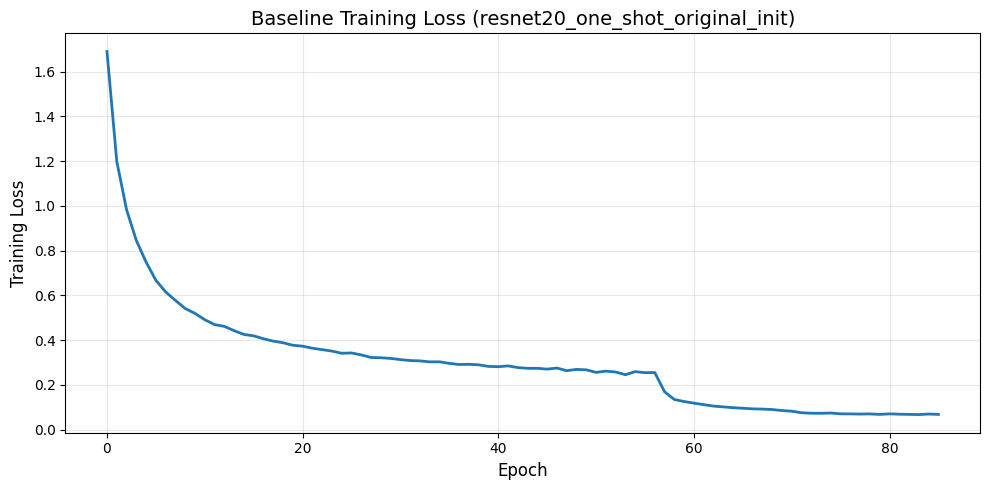

Loss figure saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/figures/baseline_loss_resnet20_one_shot_original_init_20260110_215316.png


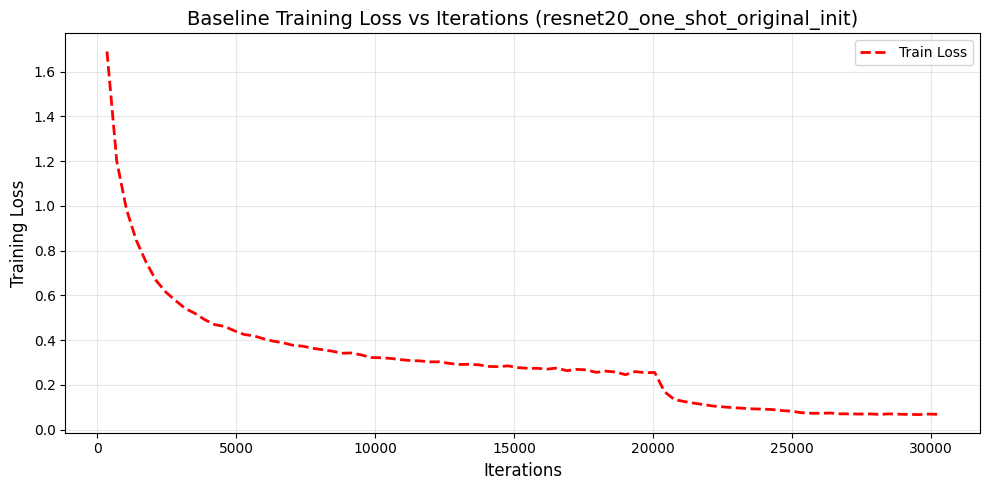

Iteration-based loss figure saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/figures/baseline_loss_iter_resnet20_one_shot_original_init_20260110_215316.png


In [ ]:
# iterations_per_epoch = len(train_loader)
# # ================= Drawing Figure 1: X-axis = Epochs =================

# plt.figure(figsize=(10, 5))
# plt.plot(losses, linewidth=2)
# plt.xlabel('Epoch', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title(f'Baseline Training Loss ({model_name})', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

# # Save with run_id
# loss_fig_path = os.path.join(fig_dir, f"baseline_loss_{run_id}.png")
# plt.savefig(loss_fig_path, dpi=150)
# plt.show()

# print(f"Loss figure saved to: {loss_fig_path}")

# # ================= Drawing Figure 2: X-axis = Iterations =================
# iterations_x = [i * iterations_per_epoch for i in range(1, len(losses) + 1)]

# plt.figure(figsize=(10, 5))
# plt.plot(iterations_x, losses, linewidth=2, color='red', linestyle='--', label='Train Loss')
# plt.xlabel('Iterations', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title(f'Baseline Training Loss vs Iterations ({model_name})', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()

# # Save Iteration Figure
# loss_fig_path_iter = os.path.join(fig_dir, f"baseline_loss_iter_{run_id}.png")
# plt.savefig(loss_fig_path_iter, dpi=150)
# plt.show()
# print(f"Iteration-based loss figure saved to: {loss_fig_path_iter}")

### Save Baseline Model

In [ ]:
# # --- Save Baseline Model ---
# # Save with the unique run_id in the filename
# baseline_path = os.path.join(ckpt_dir, f"baseline_{run_id}.pth")

# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'test_accuracy': test_accuracy,
#     'test_loss': test_loss,
#     'epochs': epochs,
#     'config': {
#         'optimizer': optimizer_name,
#         'lr': current_lr
#     }
# }, baseline_path)

# print(f"Baseline model saved to: {baseline_path}")

Baseline model saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/checkpoints/baseline_resnet20_one_shot_original_init_20260110_215316.pth


## 5. Pruning Experiments

### 5.1 Iterative Pruning

Run the main pruning experiment from the paper.

In [5]:
# Get pruning configuration for your model
# Options: 'lenet', 'conv2', 'conv4', 'conv6', 'resnet18'

# pruning_config = get_pruning_config('conv2')  # Change this for your model
pruning_config = get_pruning_config('resnet18')

print("Pruning Configuration:")
for key, value in pruning_config.items():
    print(f"  {key}: {value}")

# Or customize your own config
# pruning_config = {
#     'prune_rate_conv': 0.1,
#     'prune_rate_fc': 0.2,
#     'pruning_strategy': 'layerwise'
# }

Pruning Configuration:
  prune_rate_conv: 0.2
  prune_rate_fc: 0.0
  pruning_strategy: global
  description: ResNet-18 for CIFAR-10


In [6]:
# Create fresh model for pruning
# model_pruning = Conv2().to(device)  # Replace with your model
# model_pruning = ResNet18_CIFAR10().to(device) 
model_pruning = ResNet20_CIFAR10().to(device) 

epochs_per_round = 86  # (30k iter / 352 steps)

results = iterative_pruning(
    model=model_pruning,
    train_loader=train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={'lr': 0.1, 'momentum': 0.9, 'weight_decay': 1e-4},
    device=device,
    config=pruning_config,
    n_rounds=15,          # 15 rounds to match paper's ~90% sparsity
    epochs_per_round=epochs_per_round,  # each 30k iterations
    verbose=True
)

print("\nPruning experiment complete!")

iterative_path = os.path.join(ckpt_dir, f"iterative_original_results_{run_id}.pt")
torch.save({
    'results': results,
    'config': pruning_config,
    'initial_weights_state': initial_weights_state
}, iterative_path)
print(f"Iterative pruning results saved to: {iterative_path}")

Starting Iterative Pruning
Initial parameters: 269,722
Pruning strategy: global
Conv prune rate: 20.0%
FC prune rate: 0.0%

Round 1/15
Scheduler enabled: MultiStepLR at epochs 56 and 71
Epoch 01 | Train Loss: 1.7901 | Val Loss: 1.8071 | Val Acc: 41.22% | Test Acc: 41.59%
Epoch 02 | Train Loss: 1.2281 | Val Loss: 1.1184 | Val Acc: 60.88% | Test Acc: 60.31%
Epoch 03 | Train Loss: 0.9714 | Val Loss: 1.1242 | Val Acc: 63.50% | Test Acc: 63.65%
Epoch 04 | Train Loss: 0.8195 | Val Loss: 1.0067 | Val Acc: 67.66% | Test Acc: 66.75%
Epoch 05 | Train Loss: 0.7199 | Val Loss: 0.7700 | Val Acc: 74.86% | Test Acc: 74.27%
Epoch 06 | Train Loss: 0.6536 | Val Loss: 0.7543 | Val Acc: 74.06% | Test Acc: 74.93%
Epoch 07 | Train Loss: 0.6044 | Val Loss: 0.6862 | Val Acc: 77.02% | Test Acc: 77.21%
Epoch 08 | Train Loss: 0.5637 | Val Loss: 0.6629 | Val Acc: 78.30% | Test Acc: 77.38%
Epoch 09 | Train Loss: 0.5359 | Val Loss: 0.7459 | Val Acc: 75.44% | Test Acc: 75.55%


Epoch 10/86: 100%|██████████| 352/352 [00:05<00:00, 66.14it/s]


Epoch 10 | Train Loss: 0.5082 | Val Loss: 0.6752 | Val Acc: 78.12% | Test Acc: 78.00%
Epoch 11 | Train Loss: 0.4882 | Val Loss: 0.8446 | Val Acc: 74.70% | Test Acc: 73.46%
Epoch 12 | Train Loss: 0.4709 | Val Loss: 0.6438 | Val Acc: 78.62% | Test Acc: 79.06%
Epoch 13 | Train Loss: 0.4516 | Val Loss: 0.5557 | Val Acc: 81.52% | Test Acc: 81.02%
Epoch 14 | Train Loss: 0.4367 | Val Loss: 0.5359 | Val Acc: 82.38% | Test Acc: 81.92%
Epoch 15 | Train Loss: 0.4289 | Val Loss: 0.6400 | Val Acc: 80.30% | Test Acc: 79.18%
Epoch 16 | Train Loss: 0.4097 | Val Loss: 0.6174 | Val Acc: 80.68% | Test Acc: 80.60%
Epoch 17 | Train Loss: 0.4013 | Val Loss: 0.5830 | Val Acc: 81.38% | Test Acc: 80.91%
Epoch 18 | Train Loss: 0.3909 | Val Loss: 0.6130 | Val Acc: 80.50% | Test Acc: 80.62%
Epoch 19 | Train Loss: 0.3838 | Val Loss: 0.5341 | Val Acc: 83.18% | Test Acc: 82.17%


Epoch 20/86: 100%|██████████| 352/352 [00:05<00:00, 59.49it/s]


Epoch 20 | Train Loss: 0.3788 | Val Loss: 0.4937 | Val Acc: 84.02% | Test Acc: 83.26%
Epoch 21 | Train Loss: 0.3700 | Val Loss: 0.4264 | Val Acc: 85.76% | Test Acc: 85.02%
Epoch 22 | Train Loss: 0.3573 | Val Loss: 0.4825 | Val Acc: 84.76% | Test Acc: 84.29%
Epoch 23 | Train Loss: 0.3551 | Val Loss: 0.5511 | Val Acc: 83.04% | Test Acc: 82.67%
Epoch 24 | Train Loss: 0.3514 | Val Loss: 0.5571 | Val Acc: 83.10% | Test Acc: 83.75%
Epoch 25 | Train Loss: 0.3409 | Val Loss: 0.4600 | Val Acc: 85.16% | Test Acc: 85.25%
Epoch 26 | Train Loss: 0.3323 | Val Loss: 0.6701 | Val Acc: 78.98% | Test Acc: 79.64%
Epoch 27 | Train Loss: 0.3294 | Val Loss: 0.5115 | Val Acc: 83.84% | Test Acc: 84.15%
Epoch 28 | Train Loss: 0.3220 | Val Loss: 0.4619 | Val Acc: 85.72% | Test Acc: 85.67%
Epoch 29 | Train Loss: 0.3276 | Val Loss: 0.4586 | Val Acc: 85.84% | Test Acc: 85.25%


...

Epoch 60 | Train Loss: 0.5167 | Val Loss: 0.5588 | Val Acc: 80.62% | Test Acc: 80.81%
Epoch 61 | Train Loss: 0.5111 | Val Loss: 0.5476 | Val Acc: 81.04% | Test Acc: 81.05%
Epoch 62 | Train Loss: 0.5082 | Val Loss: 0.5673 | Val Acc: 80.80% | Test Acc: 80.74%
Epoch 63 | Train Loss: 0.5029 | Val Loss: 0.5557 | Val Acc: 81.24% | Test Acc: 80.82%
Epoch 64 | Train Loss: 0.5025 | Val Loss: 0.5425 | Val Acc: 81.54% | Test Acc: 80.99%
Epoch 65 | Train Loss: 0.5006 | Val Loss: 0.5555 | Val Acc: 80.98% | Test Acc: 80.98%
Epoch 66 | Train Loss: 0.4998 | Val Loss: 0.5433 | Val Acc: 81.52% | Test Acc: 81.39%
Epoch 67 | Train Loss: 0.5007 | Val Loss: 0.5567 | Val Acc: 81.44% | Test Acc: 80.88%
Epoch 68 | Train Loss: 0.4988 | Val Loss: 0.5537 | Val Acc: 81.10% | Test Acc: 81.10%
Epoch 69 | Train Loss: 0.4924 | Val Loss: 0.5454 | Val Acc: 82.02% | Test Acc: 80.90%


Epoch 70/86: 100%|██████████| 352/352 [00:05<00:00, 62.99it/s]


Epoch 70 | Train Loss: 0.4989 | Val Loss: 0.5431 | Val Acc: 81.56% | Test Acc: 81.20%
Epoch 71 | Train Loss: 0.4951 | Val Loss: 0.5356 | Val Acc: 81.76% | Test Acc: 81.16%
 -> Scheduler Step! Current LR: 0.0010000000000000002
Epoch 72 | Train Loss: 0.4853 | Val Loss: 0.5293 | Val Acc: 81.88% | Test Acc: 81.52%
 -> Scheduler Step! Current LR: 0.0010000000000000002
Epoch 73 | Train Loss: 0.4824 | Val Loss: 0.5303 | Val Acc: 81.94% | Test Acc: 81.64%
Epoch 74 | Train Loss: 0.4782 | Val Loss: 0.5334 | Val Acc: 81.78% | Test Acc: 81.60%
Epoch 75 | Train Loss: 0.4772 | Val Loss: 0.5324 | Val Acc: 81.74% | Test Acc: 81.53%
Epoch 76 | Train Loss: 0.4778 | Val Loss: 0.5317 | Val Acc: 81.68% | Test Acc: 81.52%
Epoch 77 | Train Loss: 0.4767 | Val Loss: 0.5341 | Val Acc: 81.60% | Test Acc: 81.52%
Epoch 78 | Train Loss: 0.4763 | Val Loss: 0.5328 | Val Acc: 81.64% | Test Acc: 81.56%
Epoch 79 | Train Loss: 0.4807 | Val Loss: 0.5311 | Val Acc: 81.80% | Test Acc: 81.55%


Epoch 80/86: 100%|██████████| 352/352 [00:05<00:00, 62.64it/s]


Epoch 80 | Train Loss: 0.4773 | Val Loss: 0.5305 | Val Acc: 81.96% | Test Acc: 81.36%
Epoch 81 | Train Loss: 0.4750 | Val Loss: 0.5321 | Val Acc: 81.92% | Test Acc: 81.40%
   [Tracker] 🚩 Early Stop Condition at Iter 28864 (Epoch 82, Test Acc: 81.47%)
Epoch 82 | Train Loss: 0.4744 | Val Loss: 0.5318 | Val Acc: 81.90% | Test Acc: 81.47%
Epoch 83 | Train Loss: 0.4782 | Val Loss: 0.5314 | Val Acc: 81.96% | Test Acc: 81.59%
Epoch 84 | Train Loss: 0.4751 | Val Loss: 0.5315 | Val Acc: 81.58% | Test Acc: 81.64%
Epoch 85 | Train Loss: 0.4721 | Val Loss: 0.5283 | Val Acc: 82.10% | Test Acc: 81.83%
Epoch 86 | Train Loss: 0.4739 | Val Loss: 0.5288 | Val Acc: 81.86% | Test Acc: 81.72%

Round 15 Results:
  Test Accuracy: 81.72%
  Remaining Parameters: 11,444.0 (4.24%)

Iterative Pruning Complete!

Pruning experiment complete!
Iterative pruning results saved to: ../../results/resnet20_iterative_original_init_20260111_183314/checkpoints/iterative_original_results_resnet20_iterative_original_init_20260

### 5.2 One-Shot

## 6. Analyze Results

### 6.1 Iterative Pruning

Visualize and analyze the pruning results.

In [ ]:
# Extract data for plotting
# Iterative pruning
rounds = [r['round'] for r in results]
test_accuracies = [r['test_accuracy'] for r in results]
remaining_params_pct = [r['remaining_params_pct'] for r in results]
remaining_params = [r['remaining_params'] for r in results]

# Print summary
print("\n" + "="*70)
print("Pruning Results Summary")
print("="*70)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Test Acc %':<12}")
print("-"*70)
for r in results:
    print(f"{r['round']:<8} {r['remaining_params_pct']:<12.2f} "
          f"{r['remaining_params']:<15,} {r['test_accuracy']:<12.2f}")
print("="*70)

KeyError: 'round'

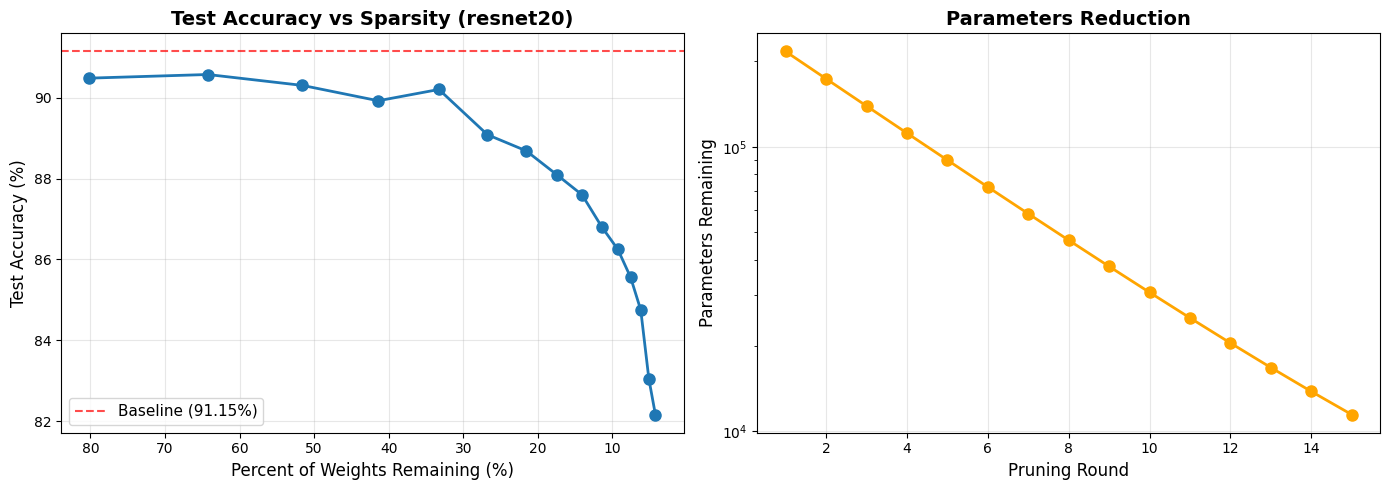

Pruning figure saved to: ../../results/resnet20_20260110_140401/figures/pruning_results_resnet20_20260110_140401.png


In [ ]:
# --- Visualize ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Sparsity
ax1.plot(remaining_params_pct, test_accuracies, 'o-', linewidth=2, markersize=8)

# Robust baseline line handling (CPU/GPU compatible)
baseline_acc_val = test_accuracy.item() if isinstance(test_accuracy, torch.Tensor) else test_accuracy
ax1.axhline(y=baseline_acc_val, color='r', linestyle='--', label=f'Baseline ({baseline_acc_val:.2f}%)', alpha=0.7)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Test Accuracy vs Sparsity ({model_name})', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.invert_xaxis() 

# Plot 2: Params Reduction
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log') # Log scale is great for pruning

plt.tight_layout()

# Save Pruning Figure
pruning_fig_path = os.path.join(fig_dir, f"Iterative_pruning_results_{run_id}.png")
plt.savefig(pruning_fig_path, dpi=150)
plt.show()

print(f"Pruning figure saved to: {pruning_fig_path}")

In [ ]:
import matplotlib.pyplot as plt
import os

# =========================================================
# Plot: Test Accuracy vs. Training Iterations (Figure 3)
# =========================================================

# 1. Setup plot
plt.figure(figsize=(12, 7))

# Get iterations per epoch for X-axis conversion
steps_per_epoch = len(train_loader)

print(f"Plotting learning curves for {len(results)} sparsity levels...")

# 2. Loop through results and plot each curve
for result in results:
    # Extract data
    sp = result['sparsity']                     # Sparsity level
    acc_history = result['history']['test_acc'] # Accuracy list
    
    # Generate X-axis (Iterations) based on steps per epoch
    iterations = [(i + 1) * steps_per_epoch for i in range(len(acc_history))]
    
    # Label using "Remaining %"
    label_str = f"{sp*100:.1f}% Remaining"
    
    # Optional: Use dashed line for very high sparsity (< 5%)
    linestyle = '--' if sp < 0.05 else '-'
    
    plt.plot(iterations, acc_history, linewidth=2, linestyle=linestyle, label=label_str)

# 3. Add Baseline reference line (Optional)
# Uncomment below if you want to show the baseline accuracy
# plt.axhline(y=90.5, color='black', linestyle=':', label='Baseline Final Acc', alpha=0.6)

# 4. Configure plot style
plt.xlabel('Training Iterations', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title(f'Test Accuracy vs Training Iterations ({model_name})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='lower right', title="Sparsity Level")

# 5. Save and display
plt.tight_layout()

# Generate path with run_id to avoid overwriting
curve_fig_path = os.path.join(fig_dir, f"Iterative_learning_curves_{run_id}.png")
plt.savefig(curve_fig_path, dpi=150)
plt.show()

print(f"Learning curve figure saved to: {curve_fig_path}")

### 6.2 One-Shot

## 7. Identify Winning Tickets

Find which pruned networks are "winning tickets" (match or exceed baseline accuracy).

In [19]:
# Identify winning tickets
baseline_accuracy = test_accuracy
winning_tickets = []

for r in results:
    # Winning ticket criteria: accuracy >= 98% of baseline
    if r['test_accuracy'] >= baseline_accuracy * 0.98:
        winning_tickets.append(r)

print(f"\n{'='*70}")
print(f"Found {len(winning_tickets)} Winning Tickets!")
print(f"{'='*70}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"\nWinning Tickets (accuracy >= {baseline_accuracy * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Accuracy %':<12}")
print("-"*70)

for ticket in winning_tickets:
    sparsity = 100 - ticket['remaining_params_pct']
    print(f"{ticket['round']:<8} {sparsity:<12.1f} "
          f"{ticket['remaining_params']:<15,} {ticket['test_accuracy']:<12.2f}")

if winning_tickets:
    best_ticket = min(winning_tickets, key=lambda x: x['remaining_params'])
    print(f"\nBest Winning Ticket:")
    print(f"  Round: {best_ticket['round']}")
    print(f"  Sparsity: {100 - best_ticket['remaining_params_pct']:.1f}%")
    print(f"  Parameters: {best_ticket['remaining_params']:,}")
    print(f"  Accuracy: {best_ticket['test_accuracy']:.2f}%")


Found 5 Winning Tickets!
Baseline Accuracy: 91.15%

Winning Tickets (accuracy >= 89.33%):
Round    Sparsity %   Params          Accuracy %  
----------------------------------------------------------------------


KeyError: 'round'

## 8. Save Results

In [ ]:
import json
import numpy as np

# Helper to convert non-serializable types
def json_serializer(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, torch.Tensor):
        return obj.item()
    raise TypeError(f"Type {type(obj)} not serializable")

# Prepare Dictionary
results_dict = {
    'run_id': run_id,
    'timestamp': timestamp,
    'model': model_name,
    'dataset': 'CIFAR-10',
    'baseline_accuracy': baseline_acc_val,
    'optimizer': optimizer_name,
    'epochs_per_round': epochs, # Assuming variable name used in loop
    'pruning_config': pruning_config,
    'pruning_results': results,
    'winning_tickets': winning_tickets # Uncomment if you implemented finding tickets logic
}

# Save JSON
json_path = os.path.join(run_dir, f"experiment_data_{run_id}.json")

with open(json_path, 'w') as f:
    json.dump(results_dict, f, indent=2, default=json_serializer)

print(f"Full results saved to: {json_path}")


RuntimeError: a Tensor with 432 elements cannot be converted to Scalar

In [22]:
import os
import json
import numpy as np

# 1. 安全过滤函数：移除包含大 Tensor 的 'mask' 字段
def filter_masks(data_list):
    clean_list = []
    for item in data_list:
        # 复制字典，排除 'mask' 键
        clean_item = {k: v for k, v in item.items() if k != 'mask'}
        clean_list.append(clean_item)
    return clean_list

# 2. 准备干净的数据
# 务必对 pruning_results 和 winning_tickets 都做清理
results_clean = filter_masks(results)
winning_tickets_clean = filter_masks(winning_tickets)

# 3. 准备字典
results_dict = {
    'run_id': run_id,
    'timestamp': timestamp,
    'model': model_name,
    'dataset': 'CIFAR-10',
    'baseline_accuracy': baseline_acc_val,
    'optimizer': optimizer_name,  # 确保你有定义这个变量，或者写 "SGD"
    'epochs_per_round': 86,       # 或者用变量 epochs
    'pruning_config': pruning_config if 'pruning_config' in locals() else "One-Shot Global",
    'pruning_results': results_clean,       # <--- 使用过滤后的数据
    'winning_tickets': winning_tickets_clean # <--- 使用过滤后的数据
}

# 4. JSON 序列化辅助函数 (保持不变)
def json_serializer(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, torch.Tensor):
        # 这里的容错性更好：如果是标量就转，如果是向量就转 list
        if obj.numel() == 1:
            return obj.item()
        else:
            return obj.tolist() # 以防万一还有其他 Tensor 列表
    raise TypeError(f"Type {type(obj)} not serializable")

# 5. 保存
json_path = os.path.join(run_dir, f"experiment_data_{run_id}.json")

with open(json_path, 'w') as f:
    json.dump(results_dict, f, indent=2, default=json_serializer)

print(f"✅ Full results (without heavy masks) saved to: {json_path}")

✅ Full results (without heavy masks) saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/experiment_data_resnet20_one_shot_original_init_20260110_215316.json


## 9. Next Steps

### Experiment Ideas:

1. **Compare pruning strategies**
   - Try different `prune_rate_conv` and `prune_rate_fc`
   - Compare `layerwise` vs `global` pruning

2. **Random reinitialization baseline**
   - Use `random_reinit_pruning()` to show winning tickets need original initialization

3. **One-shot pruning**
   - Compare `one_shot_pruning()` vs iterative pruning

4. **Visualize weight distributions**
   - Plot weight magnitude histograms before/after pruning

5. **Learning rate experiments**
   - Test different learning rates (paper shows this matters!)

## Notes and Observations

**TODO: Add your observations here**

- What worked well?
- What surprised you?
- Any implementation challenges?
- Ideas for the final report?